## Imports

In [71]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.mlab   as mlab

from kte import kernel_two_sample_test_nonuniform
from xkte_nonadaptive import kernel_two_sample_test_agnostic
from xkte_nonadaptive import kernel_dr_two_sample_test_agnostic
from dr_kte_adaptive import xMMD2_vsdr_fold_generic
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import cdist
from scipy.special import expit
from scipy.stats import bernoulli
from numpy.polynomial.polynomial import polyval
from sklearn.linear_model import LogisticRegression

from scipy.stats import norm
import scipy.stats as stats
import statistics

from tqdm import tqdm

import seaborn as sns
import pandas as pd
import time
import os

In [72]:
def treatment_effect_vector(ns, scenario, rng, beta_mix=2.0, beta_uniform=2.0):
    """
    Per-time treatment effect δ[t]; Y1 = base + δ, Y0 = base.
    scenario ∈ {'I','II','III','IV'}.
    """
    if scenario == 'I':
        return np.zeros(ns)
    if scenario == 'II':
        return np.full(ns, 2)
    if scenario == 'III':
        signs = rng.binomial(1, 0.5, size=ns) * 2 - 1
        return signs.astype(float) * beta_mix
    if scenario == 'IV':
        return rng.uniform(0, beta_uniform, size=ns)
    return np.zeros(ns)


In [84]:
ns=500
noise_var = 0.5
d = 5
beta_vec = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
scenario='II'
eps0=0.3
eps_min=0.1
power=0.1
lam=1e-3

In [85]:
rng = np.random.RandomState(0)

# contexts and potential outcomes (linear base)
X = rng.randn(ns, d)
base = X @ beta_vec 
delta = treatment_effect_vector(ns, scenario, rng)
Y0 = base + noise_var * rng.randn(ns)
Y1 = base + noise_var * rng.randn(ns) + delta

# online ridge state per arm
S0 = lam * np.eye(d); S1 = lam * np.eye(d)
b0 = np.zeros(d);      b1 = np.zeros(d)



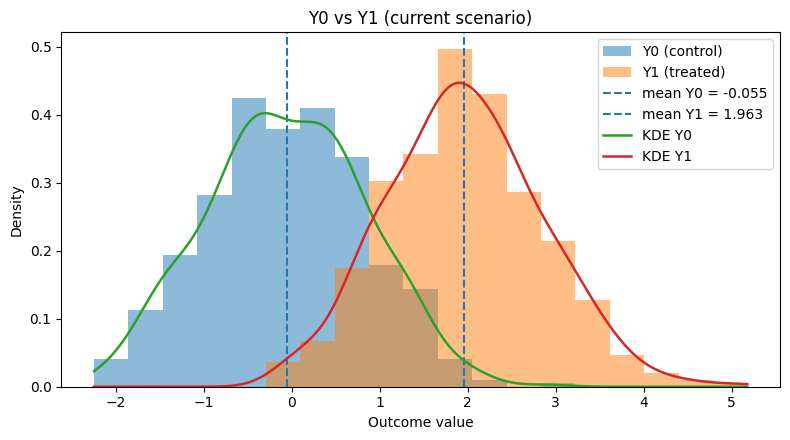

Summary:
  mean(Y0) = -0.0547,  sd(Y0) = 0.8914
  mean(Y1) = 1.9630,  sd(Y1) = 0.8816
  Δ mean (Y1 - Y0) = 2.0178
  Cohen's d ≈ 2.276


In [86]:
import numpy as np
import matplotlib.pyplot as plt

def _fd_bins(y: np.ndarray) -> int:
    """Freedman–Diaconis bin count."""
    y = np.asarray(y)
    iqr = np.subtract(*np.percentile(y, [75, 25]))
    bw = 2 * iqr / (len(y) ** (1/3) + 1e-12)
    if bw <= 0:
        return 30
    span = y.max() - y.min()
    return max(10, int(np.ceil(span / bw)))

def compare_histograms(Y0: np.ndarray,
                       Y1: np.ndarray,
                       title: str = "Outcome distributions: Y0 vs Y1",
                       alpha: float = 0.5,
                       show_kde: bool = False) -> None:
    """
    Overlaid histograms (density) + mean lines for Y0 and Y1, with shared bins.
    Parameters
    ----------
    Y0 : np.ndarray
    Y1 : np.ndarray
    title : str
    alpha : float
    show_kde : bool
        If True, also plot a quick KDE (Gaussian, fixed bandwidth) for visual aid.
        (Simple implementation to avoid external deps.)
    """
    Y0 = np.asarray(Y0).ravel()
    Y1 = np.asarray(Y1).ravel()
    Y = np.concatenate([Y0, Y1])

    # Shared bin edges
    nbins = _fd_bins(Y)
    bin_edges = np.linspace(Y.min(), Y.max(), nbins + 1)

    # Figure
    plt.figure(figsize=(8, 4.5))
    plt.hist(Y0, bins=bin_edges, density=True, alpha=alpha, label="Y0 (control)")
    plt.hist(Y1, bins=bin_edges, density=True, alpha=alpha, label="Y1 (treated)")

    # Mean lines
    m0, m1 = float(Y0.mean()), float(Y1.mean())
    s0, s1 = float(Y0.std(ddof=1)), float(Y1.std(ddof=1))
    plt.axvline(m0, linestyle="--", linewidth=1.5, label=f"mean Y0 = {m0:.3f}")
    plt.axvline(m1, linestyle="--", linewidth=1.5, label=f"mean Y1 = {m1:.3f}")

    # Optional quick KDE (simple Gaussian kernel; fixed bandwidth via Silverman rule)
    if show_kde:
        xs = np.linspace(Y.min(), Y.max(), 400)
        def kde(y):
            y = y[:, None]
            n = y.shape[0]
            std = np.std(y, ddof=1)
            h = 1.06 * std * n ** (-1/5) + 1e-12
            z = (xs[None, :] - y) / h
            dens = np.exp(-0.5 * z**2).mean(axis=0) / (np.sqrt(2*np.pi) * h)
            return dens
        plt.plot(xs, kde(Y0), linewidth=1.8, label="KDE Y0")
        plt.plot(xs, kde(Y1), linewidth=1.8, label="KDE Y1")

    # Cosmetics
    plt.title(title)
    plt.xlabel("Outcome value")
    plt.ylabel("Density")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # Quick text summary
    d_mean = m1 - m0
    pooled_sd = np.sqrt(((len(Y0)-1)*s0**2 + (len(Y1)-1)*s1**2) / (len(Y0)+len(Y1)-2))
    cohend = d_mean / (pooled_sd + 1e-12)
    print(f"Summary:")
    print(f"  mean(Y0) = {m0:.4f},  sd(Y0) = {s0:.4f}")
    print(f"  mean(Y1) = {m1:.4f},  sd(Y1) = {s1:.4f}")
    print(f"  Δ mean (Y1 - Y0) = {d_mean:.4f}")
    print(f"  Cohen's d ≈ {cohend:.3f}")

# ---- use it right after your Y0/Y1 definitions ----
compare_histograms(Y0, Y1, title="Y0 vs Y1 (current scenario)", show_kde=True)


In [87]:
def solve_theta(S, b):
    try:
        return np.linalg.solve(S, b)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(S, b, rcond=None)[0]

def eps_at(t):
    return max(eps_min, eps0 / ((t + 1) ** power))

# logs + parameter snapshots
T = np.zeros(ns, dtype=int)       # action (0/1)
w = np.zeros(ns, dtype=float)     # π_t(1|X_t) at decision time t
Y = np.zeros(ns, dtype=float)
theta0_snap = np.zeros((ns, d))
theta1_snap = np.zeros((ns, d))


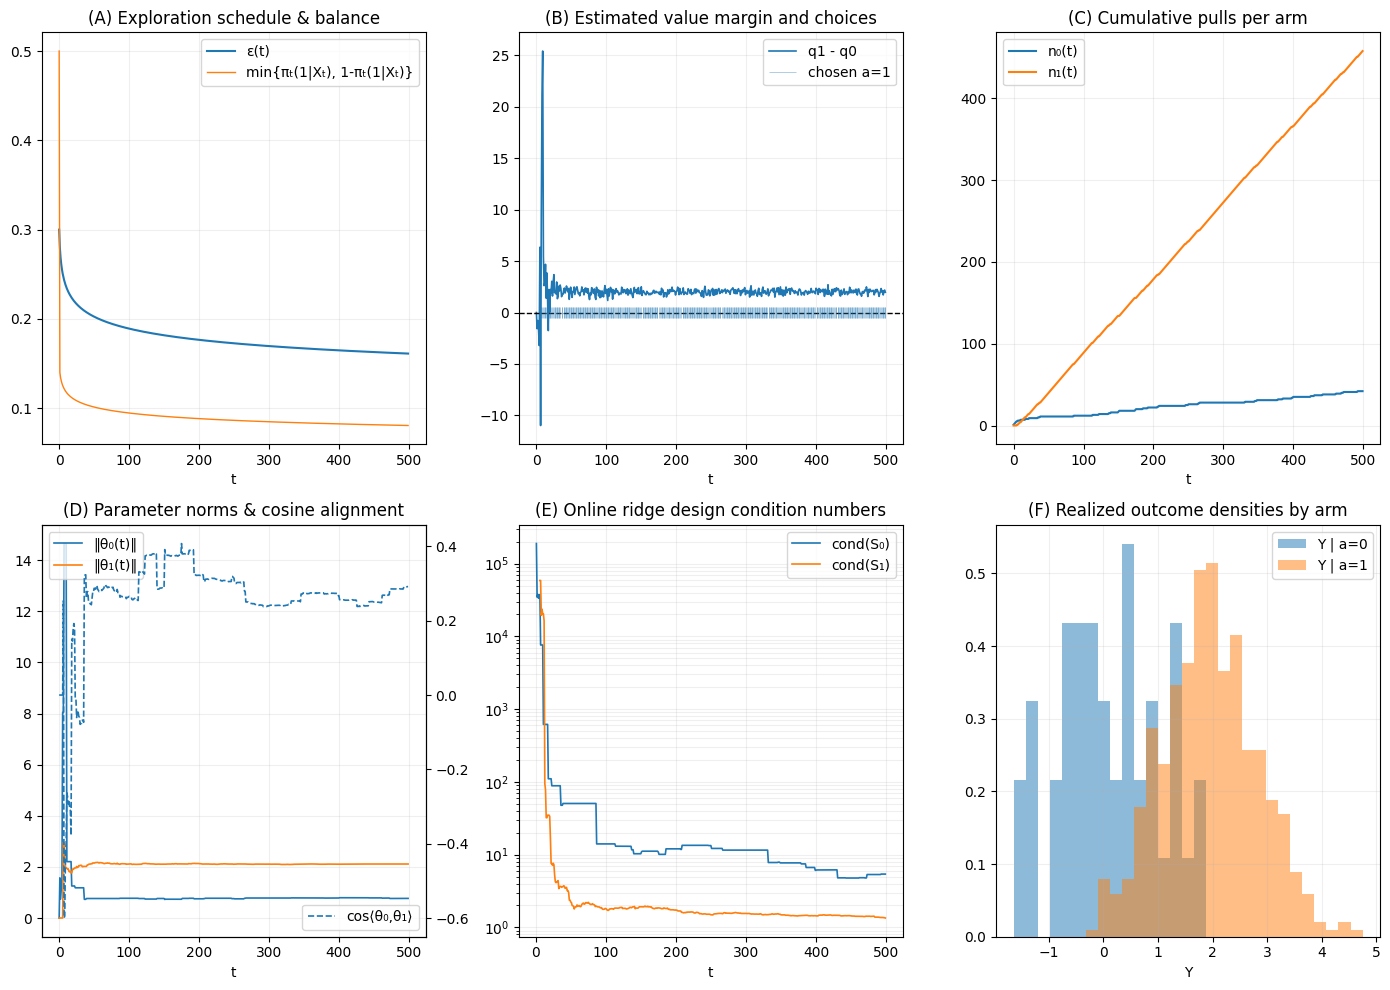

In [88]:
import numpy as np
import matplotlib.pyplot as plt


X_aug = np.hstack([np.ones((ns, 1)), X])   # [1, x]


S0 = np.diag([0.0] + [lam]*d)
S1 = np.diag([0.0] + [lam]*d)
b0 = np.zeros(d+1)
b1 = np.zeros(d+1)

theta0_snap = np.zeros((ns, d+1))
theta1_snap = np.zeros((ns, d+1))
q0_hist = np.zeros(ns); q1_hist = np.zeros(ns); margin = np.zeros(ns)
cond_S0 = np.zeros(ns); cond_S1 = np.zeros(ns); eps_hist = np.zeros(ns)
n0_cum = np.zeros(ns, dtype=int); n1_cum = np.zeros(ns, dtype=int)
pi_min_hist = np.zeros(ns)


n0 = 0
n1 = 0
for t in range(ns):
    th0 = solve_theta(S0, b0)
    th1 = solve_theta(S1, b1)
    theta0_snap[t] = th0
    theta1_snap[t] = th1

    eps_t = eps_at(t)
    z_t = X_aug[t]                 
    q0 = z_t @ th0
    q1 = z_t @ th1

    # diagnostics
    q0_hist[t] = q0
    q1_hist[t] = q1
    margin[t] = q1 - q0
    eps_hist[t] = eps_t
    cond_S0[t] = np.linalg.cond(S0)
    cond_S1[t] = np.linalg.cond(S1)

    if q1 > q0:
        pi1 = 1.0 - 0.5 * eps_t
    elif q1 < q0:
        pi1 = 0.5 * eps_t
    else:
        pi1 = 0.5

    pi_min_hist[t] = min(pi1, 1.0 - pi1)

    a = 1 if rng.rand() < pi1 else 0
    T[t] = a
    w[t] = pi1

    y_t = Y1[t] if a == 1 else Y0[t]
    Y[t] = y_t

    if a == 0:
        S0 += np.outer(z_t, z_t); b0 += z_t * y_t
        n0 += 1
    else:
        S1 += np.outer(z_t, z_t); b1 += z_t * y_t
        n1 += 1
    n0_cum[t] = n0
    n1_cum[t] = n1


# ---- plotting helper (call after the loop) ----
def _safe_cos(u, v):
    nu = np.linalg.norm(u, axis=1) + 1e-12
    nv = np.linalg.norm(v, axis=1) + 1e-12
    return (u * v).sum(axis=1) / (nu * nv)

def plot_online_diagnostics():
    t = np.arange(ns)

    # panel 1: exploration & propensity balance
    plt.figure(figsize=(14, 10))

    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(t, eps_hist, lw=1.5, label="ε(t)")
    ax1.plot(t, pi_min_hist, lw=1.0, label="min{πₜ(1|Xₜ), 1-πₜ(1|Xₜ)}")
    ax1.set_title("(A) Exploration schedule & balance")
    ax1.set_xlabel("t")
    ax1.legend()
    ax1.grid(True, alpha=0.2)

    # panel 2: value margin and decisions
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(t, margin, lw=1.2, label="q1 - q0")
    ax2.axhline(0.0, ls="--", lw=1, color="k")
    # mark chosen action (upward ticks for a=1, downward for a=0)
    tick = 0.02 * (np.nanmax(np.abs(margin)) + 1e-12)
    ax2.vlines(t[T == 1], -tick, tick, lw=0.5, label="chosen a=1", alpha=0.5)
    ax2.set_title("(B) Estimated value margin and choices")
    ax2.set_xlabel("t")
    ax2.legend()
    ax2.grid(True, alpha=0.2)

    # panel 3: cumulative arm counts
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(t, n0_cum, lw=1.5, label="n₀(t)")
    ax3.plot(t, n1_cum, lw=1.5, label="n₁(t)")
    ax3.set_title("(C) Cumulative pulls per arm")
    ax3.set_xlabel("t")
    ax3.legend()
    ax3.grid(True, alpha=0.2)

    # panel 4: parameter norms and alignment
    ax4 = plt.subplot(2, 3, 4)
    n0_norm = np.linalg.norm(theta0_snap, axis=1)
    n1_norm = np.linalg.norm(theta1_snap, axis=1)
    cos01 = _safe_cos(theta0_snap, theta1_snap)
    ax4.plot(t, n0_norm, lw=1.2, label="‖θ₀(t)‖")
    ax4.plot(t, n1_norm, lw=1.2, label="‖θ₁(t)‖")
    ax4_twin = ax4.twinx()
    ax4_twin.plot(t, cos01, lw=1.2, ls="--", label="cos⟨θ₀,θ₁⟩")
    ax4.set_title("(D) Parameter norms & cosine alignment")
    ax4.set_xlabel("t")
    ax4.legend(loc="upper left")
    ax4_twin.legend(loc="lower right")
    ax4.grid(True, alpha=0.2)

    # panel 5: design conditioning (per arm)
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(t, cond_S0, lw=1.2, label="cond(S₀)")
    ax5.plot(t, cond_S1, lw=1.2, label="cond(S₁)")
    ax5.set_yscale("log")
    ax5.set_title("(E) Online ridge design condition numbers")
    ax5.set_xlabel("t")
    ax5.legend()
    ax5.grid(True, alpha=0.2, which="both")

    # panel 6: realized outcomes by chosen arm
    ax6 = plt.subplot(2, 3, 6)
    # simple two-bin hist overlay with shared bins
    y0_obs = Y[T == 0]
    y1_obs = Y[T == 1]
    if len(y0_obs) > 0 and len(y1_obs) > 0:
        y_all = np.concatenate([y0_obs, y1_obs])
        bins = np.linspace(y_all.min(), y_all.max(), 30)
        ax6.hist(y0_obs, bins=bins, density=True, alpha=0.5, label="Y | a=0")
        ax6.hist(y1_obs, bins=bins, density=True, alpha=0.5, label="Y | a=1")
    ax6.set_title("(F) Realized outcome densities by arm")
    ax6.set_xlabel("Y")
    ax6.legend()
    ax6.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# ---- call to render ----
plot_online_diagnostics()


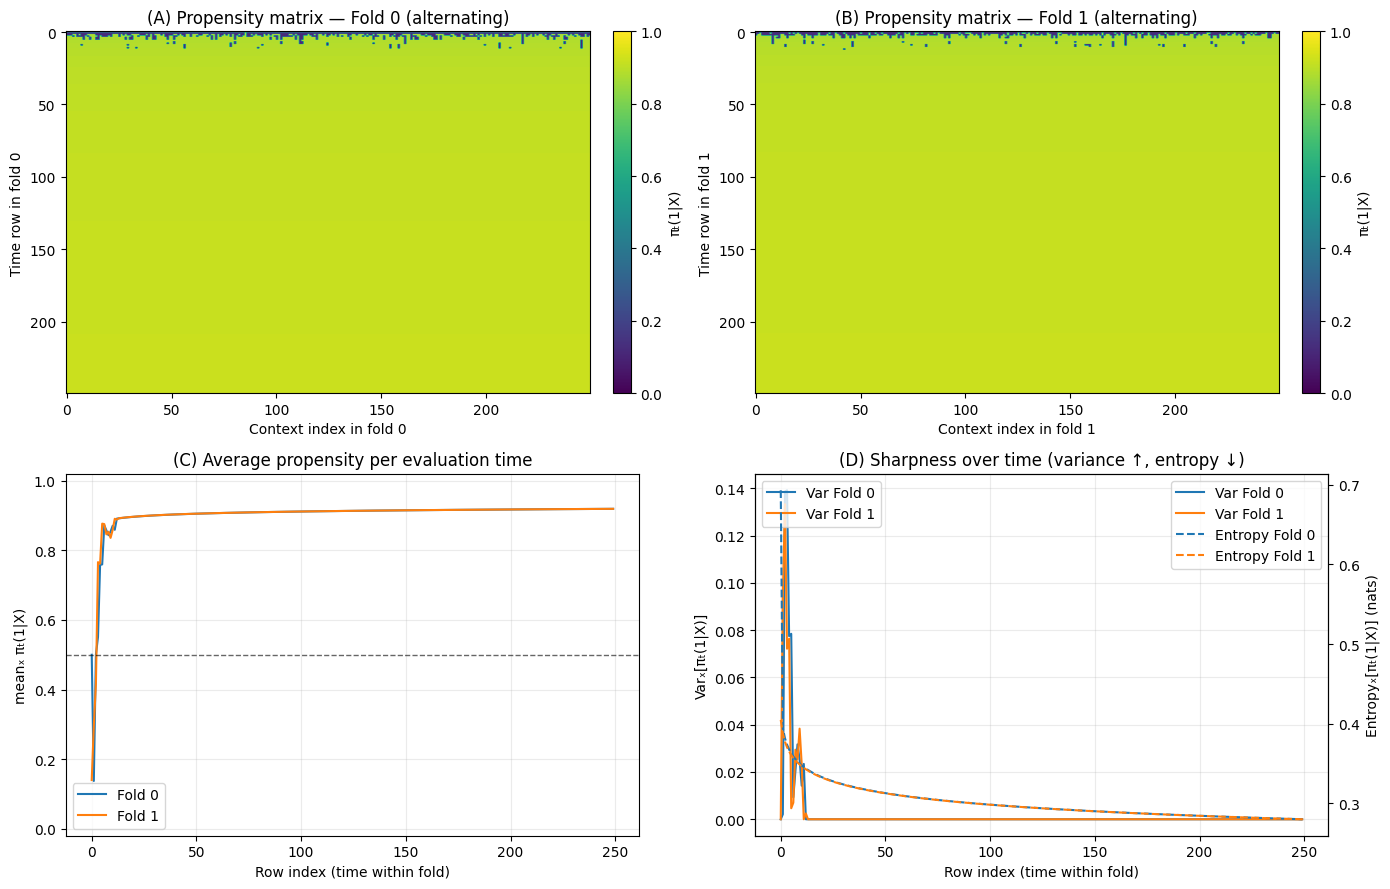

In [92]:
split='alternating'

# --- choose folds
if split == "alternating":
    idx0 = np.arange(0, ns, 2)                 # odd times in 1-based → 0,2,4,...
    idx1 = np.arange(1, ns, 2)                 # even times → 1,3,5,...
elif split == "chronological":
    cut = ns // 2
    idx0 = np.arange(0, cut)
    idx1 = np.arange(cut, ns)
else:
    raise ValueError("split must be 'alternating' or 'chronological'.")

# fold views (chronological inside each fold)
Z0, Z1 = X_aug[idx0], X_aug[idx1]   # <<< use augmented design

# build Π_{fold←fold}
N0, N1 = idx0.size, idx1.size
Pi_fold0_on_0 = np.empty((N0, N0))
for r, t in enumerate(idx0):
    th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
    q0 = Z0 @ th0; q1 = Z0 @ th1
    Pi_fold0_on_0[r] = np.where(q1 > q0, 1.0 - 0.5 * eps_t,
                                np.where(q1 < q0, 0.5 * eps_t, 0.5))

Pi_fold1_on_1 = np.empty((N1, N1))
for r, t in enumerate(idx1):
    th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
    q0 = Z1 @ th0; q1 = Z1 @ th1
    Pi_fold1_on_1[r] = np.where(q1 > q0, 1.0 - 0.5 * eps_t,
                                np.where(q1 < q0, 0.5 * eps_t, 0.5))



import numpy as np
import matplotlib.pyplot as plt

def _row_stats(P):
    avg = P.mean(axis=1)
    var = P.var(axis=1)
    # entropy in nats (clip to avoid log 0); convert to bits if you prefer / np.log(2)
    p = np.clip(P, 1e-12, 1 - 1e-12)
    ent = -(p * np.log(p) + (1 - p) * np.log(1 - p)).mean(axis=1)
    return avg, var, ent

def plot_propensity_summary(P0, P1, split_label="chronological"):
    avg0, var0, ent0 = _row_stats(P0)
    avg1, var1, ent1 = _row_stats(P1)

    fig = plt.figure(figsize=(14, 9))

    # Heatmap: fold 0
    ax1 = plt.subplot(2, 2, 1)
    im1 = ax1.imshow(P0, aspect='auto', cmap='viridis', vmin=0.0, vmax=1.0)
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="πₜ(1|X)")
    ax1.set_title(f"(A) Propensity matrix — Fold 0 ({split_label})")
    ax1.set_xlabel("Context index in fold 0")
    ax1.set_ylabel("Time row in fold 0")

    # Heatmap: fold 1
    ax2 = plt.subplot(2, 2, 2)
    im2 = ax2.imshow(P1, aspect='auto', cmap='viridis', vmin=0.0, vmax=1.0)
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label="πₜ(1|X)")
    ax2.set_title(f"(B) Propensity matrix — Fold 1 ({split_label})")
    ax2.set_xlabel("Context index in fold 1")
    ax2.set_ylabel("Time row in fold 1")

    # Row-wise averages over time
    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(avg0, label="Fold 0")
    ax3.plot(avg1, label="Fold 1")
    ax3.axhline(0.5, ls="--", lw=1, color="k", alpha=0.6)
    ax3.set_ylim(-0.02, 1.02)
    ax3.set_title("(C) Average propensity per evaluation time")
    ax3.set_xlabel("Row index (time within fold)")
    ax3.set_ylabel("meanₓ πₜ(1|X)")
    ax3.legend()
    ax3.grid(True, alpha=0.25)

    # Row-wise sharpness: variance and entropy
    ax4 = plt.subplot(2, 2, 4)
    ax4.plot(var0, label="Var Fold 0")
    ax4.plot(var1, label="Var Fold 1")
    ax4.set_title("(D) Sharpness over time (variance ↑, entropy ↓)")
    ax4.set_xlabel("Row index (time within fold)")
    ax4.set_ylabel("Varₓ[πₜ(1|X)]")
    ax4.grid(True, alpha=0.25)
    ax4.legend(loc="upper left")

    # twin y for entropy (lower = more deterministic)
    ax4b = ax4.twinx()
    ax4b.plot(ent0, ls="--", label="Entropy Fold 0")
    ax4b.plot(ent1, ls="--", label="Entropy Fold 1")
    ax4b.set_ylabel("Entropyₓ[πₜ(1|X)] (nats)")
    # combine legends
    lines, labels = ax4.get_legend_handles_labels()
    lines2, labels2 = ax4b.get_legend_handles_labels()
    ax4b.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.tight_layout()
    plt.show()

# ---- call it ----
plot_propensity_summary(Pi_fold0_on_0, Pi_fold1_on_1, split_label=split)



In [93]:
import numpy as np
from sklearn.metrics import pairwise_kernels, pairwise_distances
import scipy.stats as st

# ---------- helpers


def chronological_folds(N):
    """I_0 = {0,...,N//2-1}, I_1 = {N//2,...,N-1} (0-based)."""
    cut = N // 2
    return np.arange(cut), np.arange(cut, N)


def alternating_folds(N, one_indexed=True):
    """
    I_0 = odd times (1,3,5,...) -> 0-based [0,2,4,...]
    I_1 = even times (2,4,6,...) -> 0-based [1,3,5,...]
    """
    all_idx = np.arange(N)
    if one_indexed:
        idx0 = all_idx[0::2]
        idx1 = all_idx[1::2]
    else:
        idx0 = all_idx[::2]
        idx1 = all_idx[1::2]
    return idx0, idx1


def _precompute_fold_quadratics(KFF, R, Delta):
    KDelta = KFF @ Delta
    KR = KFF @ R
    v_dd = np.sum(Delta * (KFF @ Delta), axis=0)
    v_dr = np.sum(Delta * KR, axis=0)
    v_rr = np.sum(R * KR, axis=0)
    return v_dd, v_dr, v_rr, KDelta, KR


def _build_mu_R_Delta(KXX_fold, A_fold, lam):
    """
    Build coefficient-space (dual) KRR operators, zero-padded to N×N.
    Columns index samples (chrono order), output is dual coefficients.
    """
    n = A_fold.size
    idx_control = np.where(A_fold == 0)[0]
    idx_treated = np.where(A_fold == 1)[0]
    if idx_control.size == 0 or idx_treated.size == 0:
        raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

    m_control, n_treated = idx_control.size, idx_treated.size

    # Gram blocks in chronological order
    K_cc = KXX_fold[np.ix_(idx_control, idx_control)]  # controls
    K_ct = KXX_fold[np.ix_(idx_control, idx_treated)]
    K_tc = KXX_fold[np.ix_(idx_treated, idx_control)]
    K_tt = KXX_fold[np.ix_(idx_treated, idx_treated)]

    # Dual (hat) operators: μ̃0, μ̃1
    mu0 = np.linalg.solve(
        K_cc + lam * np.eye(m_control), np.hstack([K_cc, K_ct])
    )  # shape (m_control × N)
    mu1 = np.linalg.solve(
        K_tt + lam * np.eye(n_treated), np.hstack([K_tc, K_tt])
    )  # shape (n_treated × N)

    # Zero-pad to N×N
    mu0_pad = np.vstack([mu0, np.zeros((n_treated, n))])
    mu1_pad = np.vstack([np.zeros((m_control, n)), mu1])

    mu = mu0_pad + mu1_pad
    R = np.eye(n) - mu
    Delta = mu1_pad - mu0_pad
    return R, Delta


def _fold_omegas(KFF, R, Delta, A_fold, w_fold, Pi_fold_on_fold):
    n = A_fold.size
    denom = np.where(A_fold == 0, 1.0 - w_fold, w_fold)

    v_dd, v_dr, v_rr, KDelta, KR = _precompute_fold_quadratics(KFF, R, Delta)
    omega = np.zeros(n, dtype=float)

    for t in range(n):
        p_t = Pi_fold_on_fold[t]
        s_t = np.where(A_fold == 0, -1.0 / (1.0 - p_t), 1.0 / p_t)
        num = np.where(A_fold == 0, 1.0 - p_t, p_t)
        rho = num / denom

        past_mask = (np.arange(n) < t).astype(float)
        S_size = int(past_mask.sum())
        if S_size == 0:
            omega[t] = 0.0
            continue

        u_t = (rho * past_mask) / S_size
        v_t = s_t * u_t

        q_diag = v_dd + 2.0 * s_t * v_dr + (s_t**2) * v_rr
        M2 = np.sum((rho * past_mask) * q_diag) / S_size

        z = Delta @ u_t
        q = R @ v_t
        Kz = KDelta @ u_t
        Kq = KR @ v_t
        M1_sq = z @ Kz + 2.0 * (z @ Kq) + q @ Kq

        var_t = M2 - M1_sq
        omega[t] = 0.0 if var_t <= 0.0 else 1.0 / np.sqrt(var_t)

    return omega


def xMMD2_vsdr_fold_generic(
    Y, w, X, A, kernel_function, Pi_0_on_0, Pi_1_on_1, idx0, idx1, lam=None, **kwargs
):
    Y = np.asarray(Y)
    Y = Y[:, None] if Y.ndim == 1 else Y
    X = np.asarray(X)
    X = X[:, None] if X.ndim == 1 else X
    A = np.asarray(A, int).ravel()
    w = np.asarray(w).ravel()

    # Split folds
    Y_split0, Y_split1 = Y[idx0], Y[idx1]
    X_split0, X_split1 = X[idx0], X[idx1]
    A_split0, A_split1 = A[idx0], A[idx1]
    w_split0, w_split1 = w[idx0], w[idx1]

    # Choose gamma from second fold (as before); lam defaults to gamma
    gamma = np.median(pairwise_distances(X_split1, X_split1, metric="euclidean")) ** 2
    if lam is None:
        lam = gamma

    # Covariate kernel within each fold
    KX0 = pairwise_kernels(X_split0, X_split0, metric="rbf", gamma=1.0 / gamma)
    KX1 = pairwise_kernels(X_split1, X_split1, metric="rbf", gamma=1.0 / gamma)

    # Dual-space R, Δ
    R0, Delta0 = _build_mu_R_Delta(KX0, A_split0, lam)
    R1, Delta1 = _build_mu_R_Delta(KX1, A_split1, lam)

    # Observed DR multipliers
    W_split0_obs = np.where(A_split0 == 0, -1.0 / (1.0 - w_split0), 1.0 / w_split0)
    W_split1_obs = np.where(A_split1 == 0, -1.0 / (1.0 - w_split1), 1.0 / w_split1)

    # DR operators
    M0 = Delta0 + R0 * W_split0_obs[None, :]
    M1 = Delta1 + R1 * W_split1_obs[None, :]

    # Outcome kernels
    K00 = pairwise_kernels(Y_split0, Y_split0, metric=kernel_function, **kwargs)
    K11 = pairwise_kernels(Y_split1, Y_split1, metric=kernel_function, **kwargs)
    K01 = pairwise_kernels(Y_split0, Y_split1, metric=kernel_function, **kwargs)

    # Cross matrix
    G0 = M0.T @ K01 @ M1

    # Variance stabilization weights
    omega_split0 = _fold_omegas(K00, R0, Delta0, A_split0, w_split0, Pi_0_on_0)
    omega_split1 = _fold_omegas(K11, R1, Delta1, A_split1, w_split1, Pi_1_on_1)

    # Stabilize + normalize
    G = G0 / (omega_split0[:, None] * omega_split1[None, :] + 1e-12)
    S = np.mean(G)
    psi_cross_hat = np.mean(G**2)
    T_stat = np.sqrt(G.shape[0] * G.shape[1]) * S / np.sqrt(psi_cross_hat + 1e-12)
    return float(T_stat), omega_split0, omega_split1


def xMMD2_vsdr_fold(
    XY,
    w,
    Xcov,
    A,
    kernel_function,
    Pi_fold0_on_fold0,
    Pi_fold1_on_fold1,
    split="chronological",
    one_indexed=True,
    lam=None,
    **kwargs
):
    """
    Unified VS-DR xKTE:
      split = "chronological" -> first half vs second half
      split = "alternating"   -> odd vs even times (controlled by one_indexed)
    Pi_* matrices must be aligned with the *chronological order within each chosen fold*.
    """
    N = len(A)
    if split == "chronological":
        idx0, idx1 = chronological_folds(N)
    elif split == "alternating":
        idx0, idx1 = alternating_folds(N, one_indexed=one_indexed)
    else:
        raise ValueError("split must be 'chronological' or 'alternating'.")

    return xMMD2_vsdr_fold_generic(
        XY,
        w,
        Xcov,
        A,
        kernel_function,
        Pi_0_on_0=Pi_fold0_on_fold0,
        Pi_1_on_1=Pi_fold1_on_fold1,
        idx0=idx0,
        idx1=idx1,
        lam=lam,
        **kwargs
    )

    


In [105]:
from sklearn.metrics import pairwise_distances

if Y.ndim == 1:
    Y = Y[:, None]
YY0 = Y[T == 0]
YY1 = Y[T == 1]
sigma2 = np.median(pairwise_distances(YY0, YY1, metric='euclidean'))**2
T_stat, omega0, omega1 = xMMD2_vsdr_fold_generic(Y=Y, w=w, X=X, A=T,
                            kernel_function='rbf',
                            # fold-wise evaluation policies (chrono×chrono) for the two folds
                            Pi_0_on_0=Pi_fold0_on_0,
                            Pi_1_on_1=Pi_fold1_on_1,
                            # fold indices (0-based, chronological within each)
                            idx0=idx0,
                            idx1=idx1,
                            # outcome-kernel parameter (same as before)
                            gamma=1.0/sigma2)

In [106]:
def plot_omegas(omega0, omega1, split_label="chronological"):
    fig, axs = plt.subplots(1, 2, figsize=(12,4), sharey=True)

    axs[0].plot(omega0, label="ω Fold 0")
    axs[0].set_title(f"(A) ω_t per time — Fold 0 ({split_label})")
    axs[0].set_xlabel("t (within fold)")
    axs[0].set_ylabel("ω_t")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(omega1, label="ω Fold 1", color="orange")
    axs[1].set_title(f"(B) ω_t per time — Fold 1 ({split_label})")
    axs[1].set_xlabel("t (within fold)")
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


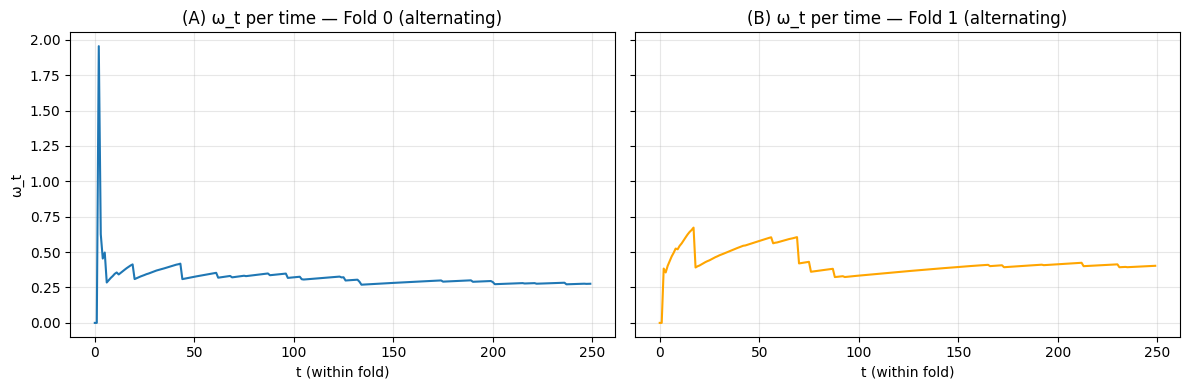

In [107]:
plot_omegas(omega0, omega1, split_label="alternating")